In [1]:
#import librararies
import numpy as np
import pandas as pd

df= pd.read_excel("ABC_Company.xlsx")

df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [2]:
#table information check

df.info()

# Peprocessing:

df["Height"] = np.random.randint(150, 181, size=len(df))
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,157,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,178,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,179,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,158,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,171,231,NaN,5000000.0


In [3]:
#Analysis Tasks:

team_count = df["Team"].value_counts()

print(team_count)

team_percentage = (
    df["Team"].value_counts(normalize=True) * 100
)

print(team_percentage)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
New York Knicks           16
Milwaukee Bucks           16
Brooklyn Nets             15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Denver Nuggets            15
Washington Wizards        15
Miami Heat                15
Charlotte Hornets         15
Atlanta Hawks             15
San Antonio Spurs         15
Houston Rockets           15
Boston Celtics            15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Sacramento Kings          15
Phoenix Suns              15
Los Angeles Lakers        15
Los Angeles Clippers      15
Golden State Warriors     15
Toronto Raptors           15
Philadelphia 76ers        15
Dallas Mavericks          15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz               

In [10]:
#Determine the distribution of employees across each team and calculate
# the percentage split relative to the total number of employees.

import matplotlib.pyplot as plt

# Employee count in each team
team_count = df["Team"].value_counts()

# Percentage of employees in each team
team_percentage = (team_count / len(df)) * 100



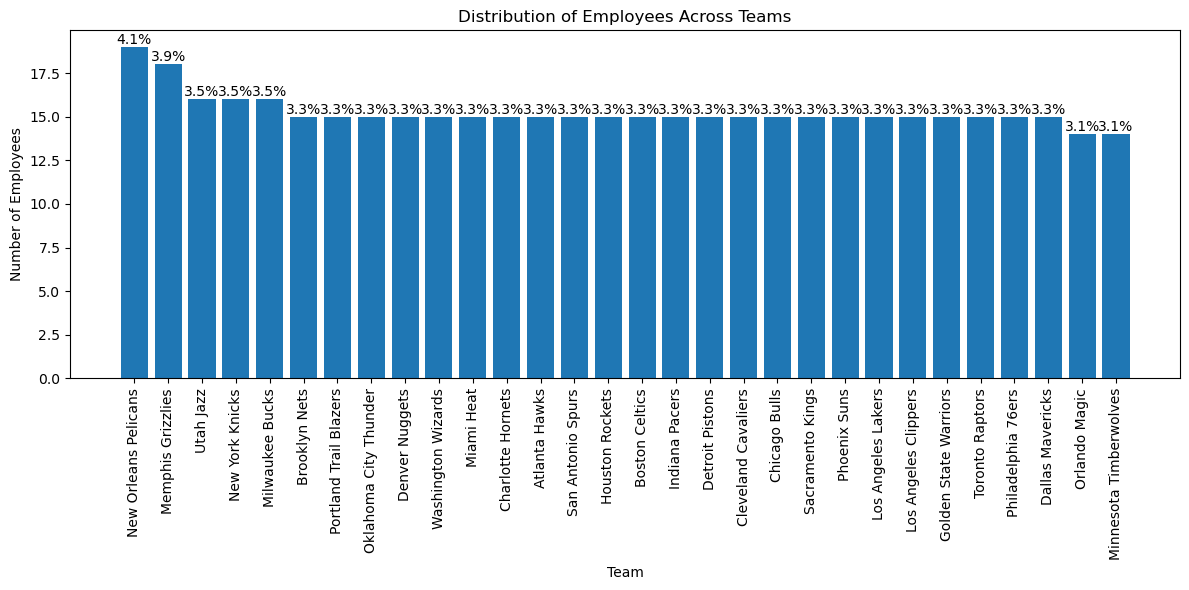

In [11]:
# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(team_count.index, team_count.values)

# Display percentage above each bar
for bar, percentage in zip(bars, team_percentage):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
#Segregate employees based on their positions within the company.

position_count = df["Position"].value_counts()
print(position_count)

#Identify the predominant age group among employees.

bins = [19, 24, 29, 34, 39, 100]
labels = ["20-24", "25-29", "30-34", "35-39", "40+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_group_count = df["Age Group"].value_counts()

print(age_group_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64
Age Group
25-29    182
20-24    152
30-34     90
35-39     29
40+        3
Name: count, dtype: int64


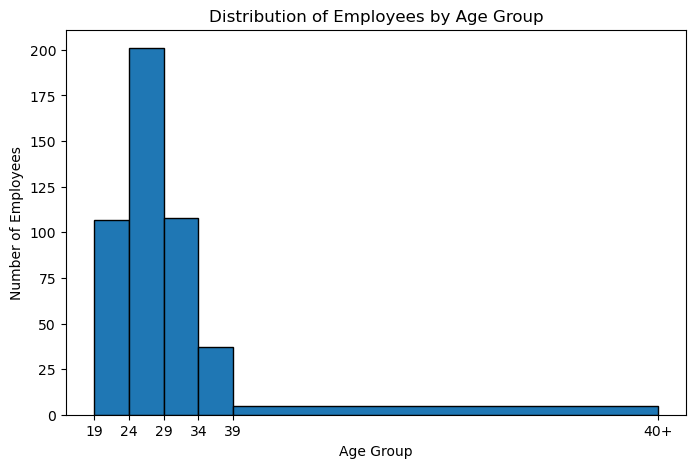

In [13]:
#Histogram representation of data

import matplotlib.pyplot as plt

# Create histogram
plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"],
    bins=[19, 24, 29, 34, 39, 100],
    edgecolor="black"
)

plt.title("Distribution of Employees by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.xticks(
    [19, 24, 29, 34, 39, 100],
    ["19", "24", "29", "34", "39", "40+"]
)

plt.show()


In [14]:
# Discover which team and position have the highest salary expenditure.

team_salary = (
    df.groupby("Team")["Salary"]
      .sum()
      .sort_values(ascending=False)
)

#based on position

position_salary = (
    df.groupby("Position")["Salary"]
      .sum()
      .sort_values(ascending=False)
)


#plotimport matplotlib.pyplot as plt

# Calculate total salary by team
team_salary = (
    df.groupby("Team")["Salary"]
    .sum()
    .sort_values(ascending=False)
)


In [15]:
# Calculate total salary by position
position_salary = (
    df.groupby("Position")["Salary"]
    .sum()
    .sort_values(ascending=False)
)

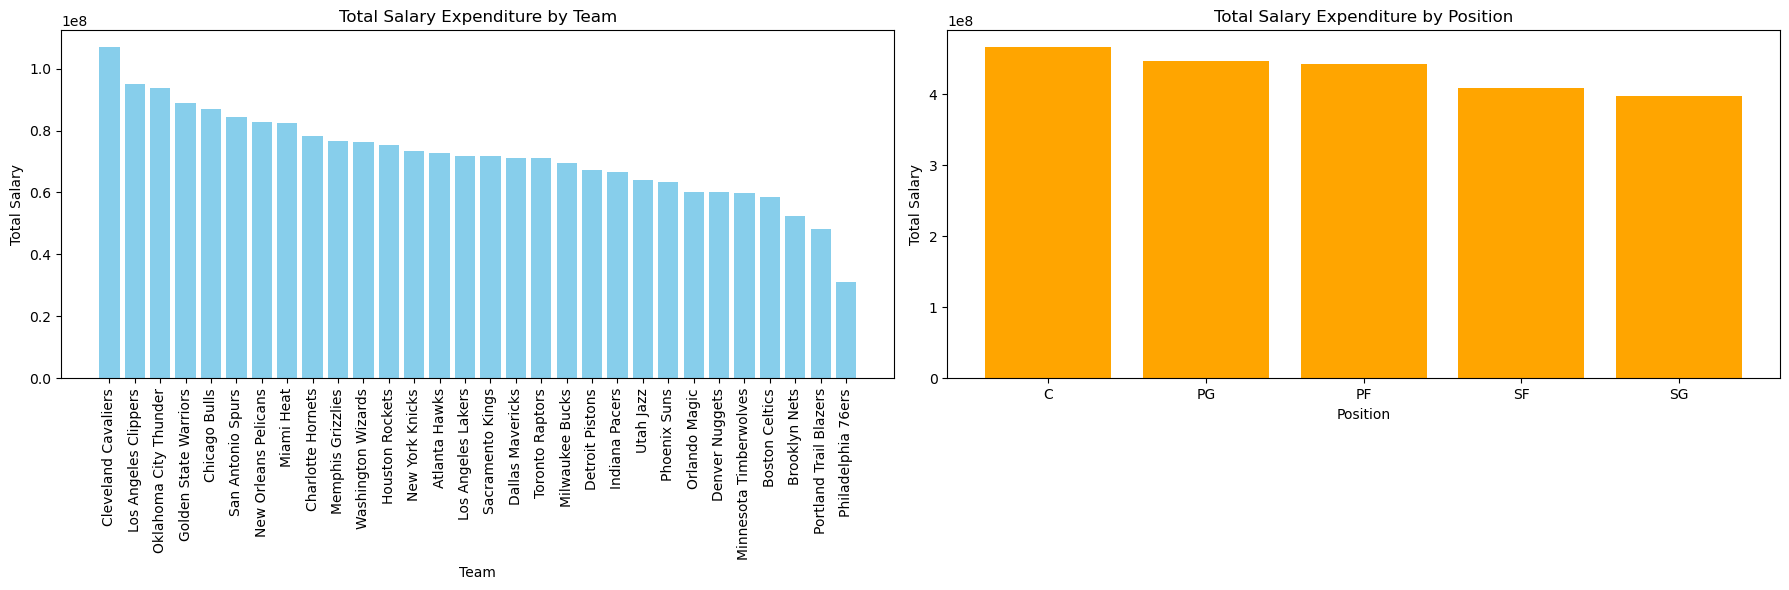

In [16]:
# Create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# First subplot: Total salary by team
axes[0].bar(team_salary.index, team_salary.values, color="skyblue")
axes[0].set_title("Total Salary Expenditure by Team")
axes[0].set_xlabel("Team")
axes[0].set_ylabel("Total Salary")
axes[0].tick_params(axis="x", rotation=90)

# Second subplot: Total salary by position
axes[1].bar(position_salary.index, position_salary.values, color="orange")
axes[1].set_title("Total Salary Expenditure by Position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Total Salary")

# Adjust spacing
plt.tight_layout()
plt.show()

In [17]:
# Finding Highest salary expenditure

print("Team with highest salary expenditure:", team_salary.idxmax())
print("Total team salary:", team_salary.max())

print("Position with highest salary expenditure:", position_salary.idxmax())
print("Total position salary:", position_salary.max())


Team with highest salary expenditure: Cleveland Cavaliers
Total team salary: 106988689.0
Position with highest salary expenditure: C
Total position salary: 466377332.0


In [18]:
# Result will be :

# Team with highest salary expenditure: Cleveland Cavaliers
# Total team salary: 106988689.0
# Position with highest salary expenditure: C
# Total position salary: 466377332.0


# Investigate if there's any correlation between age and salary, and
# represent it visually.


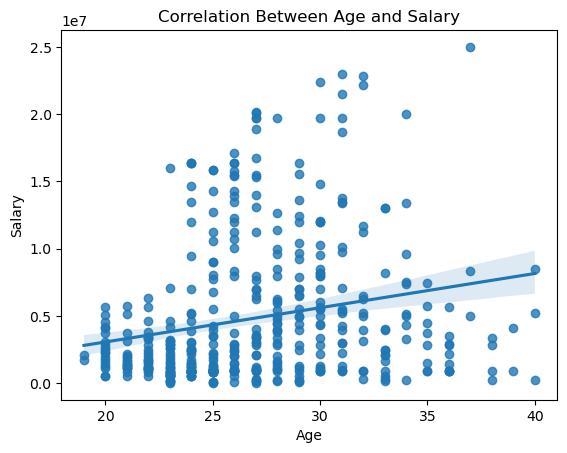

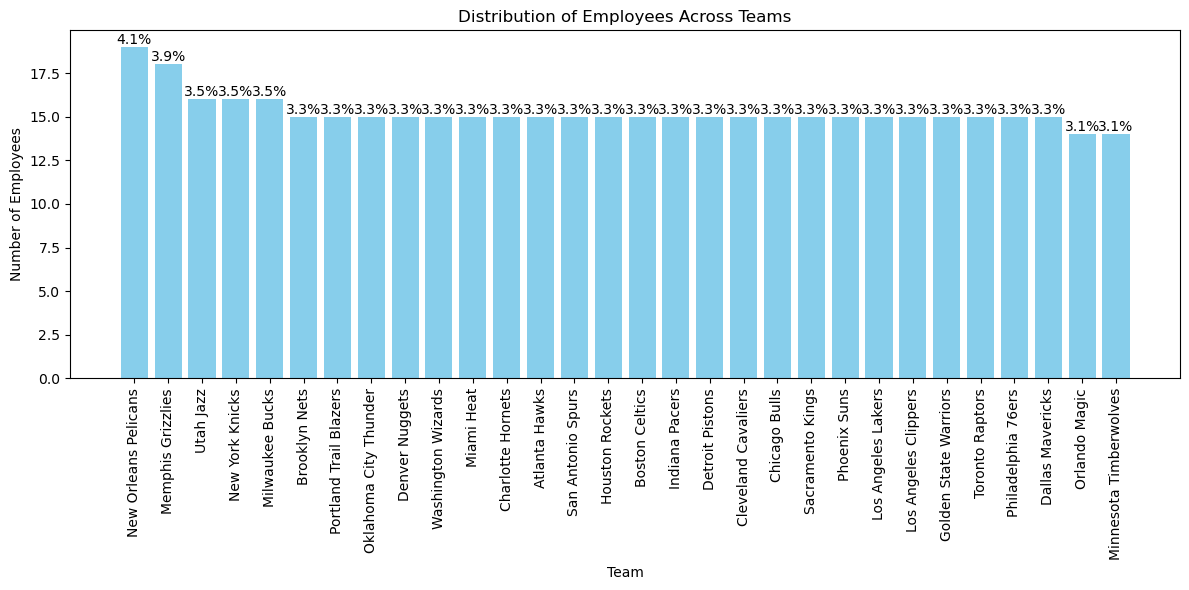

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=df, x="Age", y="Salary")
plt.title("Correlation Between Age and Salary")
plt.show()

# Correlation does not prove causation. This analysis alone cannot establish that age is the cause of changes in salary.


#Graphical Representation:

# For each of the five analysis tasks above, create appropriate visualizations
# to present your findings effectively.

# 1. Team Distribution and Percentage — Bar Chart

# Employee count and percentage by team
team_count = df["Team"].value_counts()
team_percentage = (team_count / len(df)) * 100

plt.figure(figsize=(12, 6))
bars = plt.bar(team_count.index, team_count.values, color="skyblue")

# Add percentage above each bar
for bar, percentage in zip(bars, team_percentage):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Employees Across Teams")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


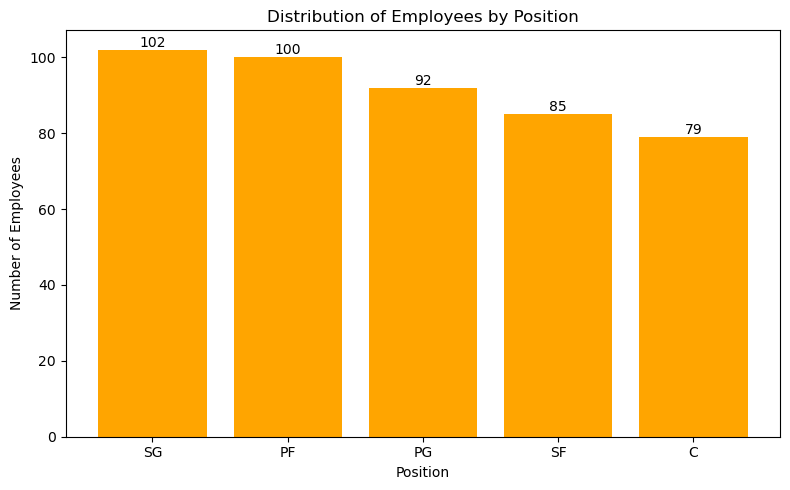

In [20]:
# 2. Position Distribution — Bar Chart

# Employee count by position
position_count = df["Position"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    position_count.index,
    position_count.values,
    color="orange"
)

# Add employee count above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Employees by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

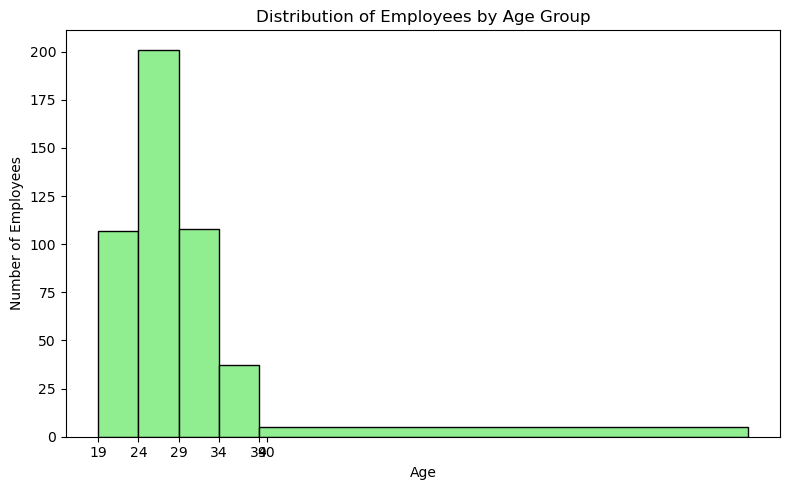

In [21]:
# 3. Age-Group Distribution — Histogram

# Age-group boundaries
age_bins = [19, 24, 29, 34, 39, 100]

plt.figure(figsize=(8, 5))

plt.hist(
    df["Age"].dropna(),
    bins=age_bins,
    color="lightgreen",
    edgecolor="black"
)

plt.title("Distribution of Employees by Age Group")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.xticks([19, 24, 29, 34, 39, 40])
plt.tight_layout()
plt.show()

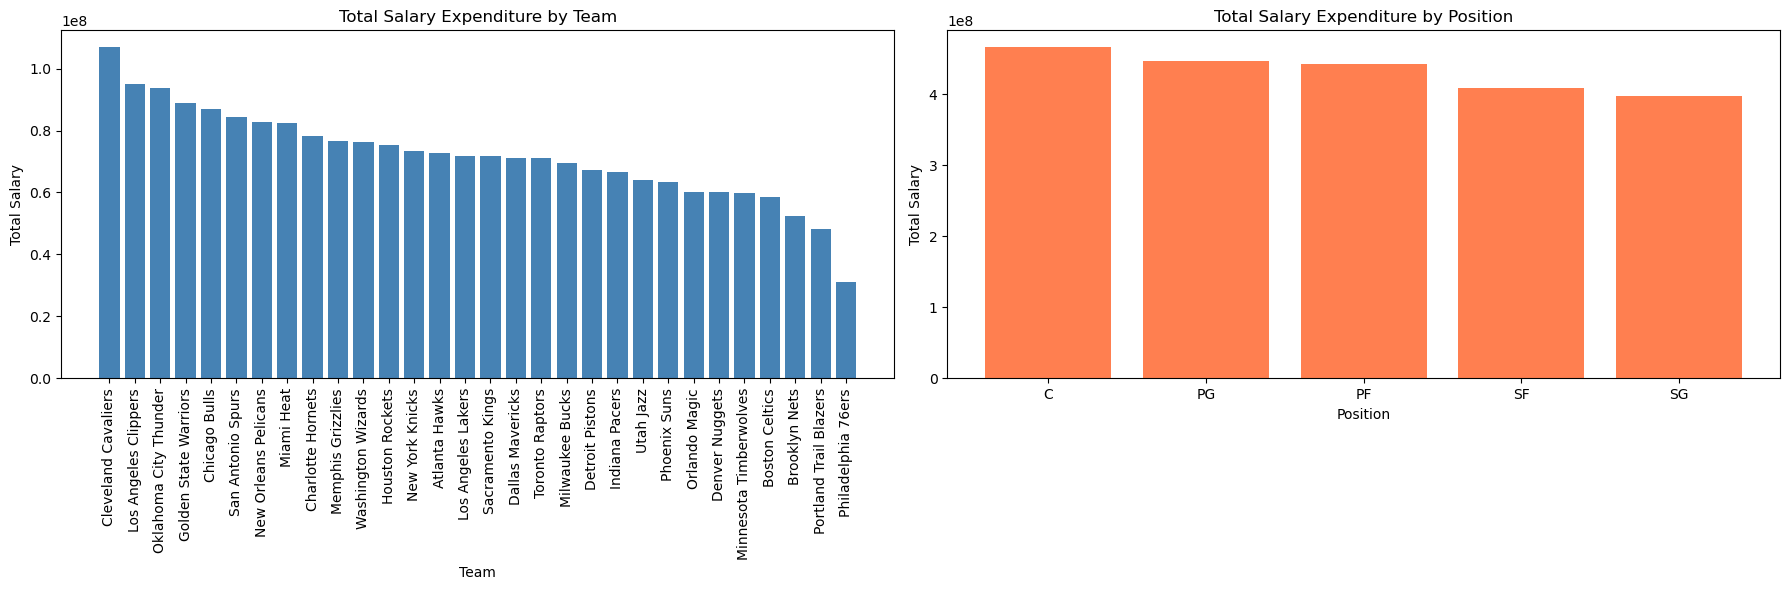

In [22]:
# 4. Salary Expenditure — Two Bar Charts

# Total salary expenditure by team
team_salary = (
    df.groupby("Team")["Salary"]
    .sum()
    .sort_values(ascending=False)
)

# Total salary expenditure by position
position_salary = (
    df.groupby("Position")["Salary"]
    .sum()
    .sort_values(ascending=False)
)

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Team salary chart
axes[0].bar(
    team_salary.index,
    team_salary.values,
    color="steelblue"
)

axes[0].set_title("Total Salary Expenditure by Team")
axes[0].set_xlabel("Team")
axes[0].set_ylabel("Total Salary")
axes[0].tick_params(axis="x", rotation=90)

# Position salary chart
axes[1].bar(
    position_salary.index,
    position_salary.values,
    color="coral"
)

axes[1].set_title("Total Salary Expenditure by Position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Total Salary")

plt.tight_layout()
plt.show()

In [23]:
# 5. Age–Salary Correlation — Scatter Plot with Regression Line


# Calculate correlation
correlation = df["Age"].corr(df["Salary"])

print("Correlation between Age and Salary:", correlation)


Correlation between Age and Salary: 0.21400941226570974


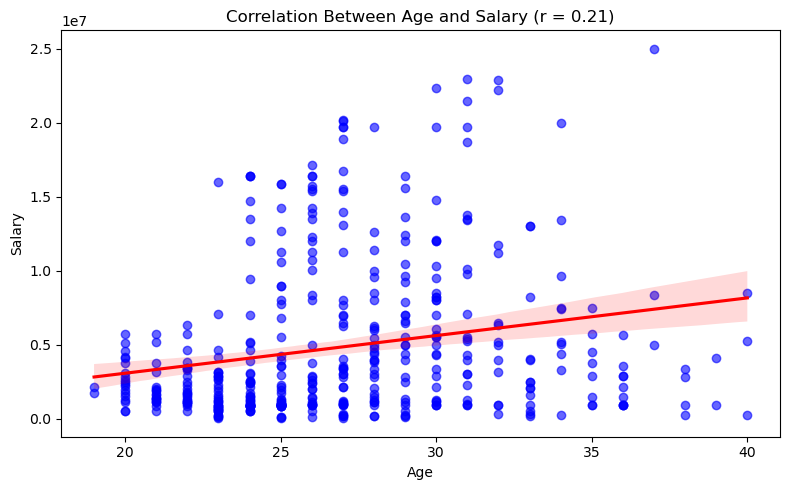

In [24]:
# Scatter plot with regression line
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Age",
    y="Salary",
    scatter_kws={"color": "blue", "alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title(
    f"Correlation Between Age and Salary (r = {correlation:.2f})"
)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [25]:
# Data Story

# Based on the dataset analysis, the "New Orleans Pelicans"  team has the highest number of employees( 16 employees), 
# representing  4.148472  % of the total workforce. The most common employee position is SG   , indicating that a larger number of employees work in this role.

# The predominant age group among employees is  25-29 (count is 182), showing that most employees fall within this age range. Regarding salary expenditure, the Cleveland Cavaliers  team has the highest total salary expenditure, while the C position accounts for the highest salary expenditure among all positions.

# The correlation coefficient between age and salary is positive correlation between age and salary (ecause the regression line slopes upward from left to right.). This indicates a weak/moderate/strong positive/negative relationship between the two variables. However, correlation does not prove causation, so this analysis alone cannot establish that age causes changes in salary.

# Overall, the analysis provides useful insights into employee distribution, workforce demographics, salary allocation, and the relationship between employee age and salary. Replace the blank spaces with the actual results obtained from your analysis.